# Homework 6


Note: Our group, Kymanni and I, spent 4 hours working together on May 4 at 4:00 PM. We're not exactly sure what's going on with our other groupmate, Jaiden. (RS).

## 34-2 Bonnie and Clyde

To note for myself, a problem is **tractable** if it has a polynomial-time algorithm, and a decision problem is **NP-complete** if it is in $NP$ and a known NP-complete problem reduces to it in polynomial time. For the NP-completeness proofs, the certificate is the subset of items that Bonnie receives. I am assuming that the integer values are part of the input, written in binary. I am also using `SUBSET-SUM` as the known NP-complete problem from the textbook: given nonnegative integers $a_1,\dots,a_n$ and a target $t$, decide whether some subset sums to exactly $t$.


## 34-2 [a]

The bag contains $n$ coins, but only 2 different denominations: some coins are worth $x$ dollars, and some are worth $y$ dollars. Bonnie and Clyde wish to divide the money exactly evenly.

#### My answer:
This has a polynomial-time algorithm.

#### My algorithm:
Count how many coins have value $x$ and how many have value $y$. Say those counts are $a$ and $b$. The total value is
$$
S=ax+by.
$$
If $S$ is odd, then there is no exact split. Otherwise Bonnie's target amount is
$$
T=\frac{S}{2}.
$$

Now try every possible number $i$ of $x$-coins that Bonnie could take:
$$
0\le i\le a.
$$
Once $i$ is chosen, there is no choice left for the number of $y$-coins. It would have to be
$$
j=\frac{T-ix}{y}.
$$
If $j$ is an integer and $0\le j\le b$, then we accept. Otherwise keep trying the next $i$. If none of the $i$ values work, reject.

#### Why it works:
Any possible split is described just by the pair $(i,j)$, where Bonnie gets $i$ coins of value $x$ and $j$ coins of value $y$. The algorithm checks every possible value of $i$, and for each one it computes the only $j$ that could possibly work. So if a solution exists, the algorithm finds it. If the algorithm accepts, then it found integers with
$$
ix+jy=T,
$$
so Bonnie gets exactly half the money.

#### Running time:
Counting the coins takes $O(n)$ time. The loop has at most $a+1\le n+1$ iterations, and each iteration only does basic arithmetic on the input integers. So the running time is polynomial in the input size.


#### SymPy / Matplotlib check:


sample coins: [6, 6, 6, 6, 6, 10, 10, 10]
target: 30
algorithm says: True with i,j = (0, 3)
SymPy equation for the sample: Eq(6*I + 10*J, 30)
SymPy solves it as: 3 - 3*I/5 for J
checking witness in SymPy: True
algorithm matches brute force on all small tests: True


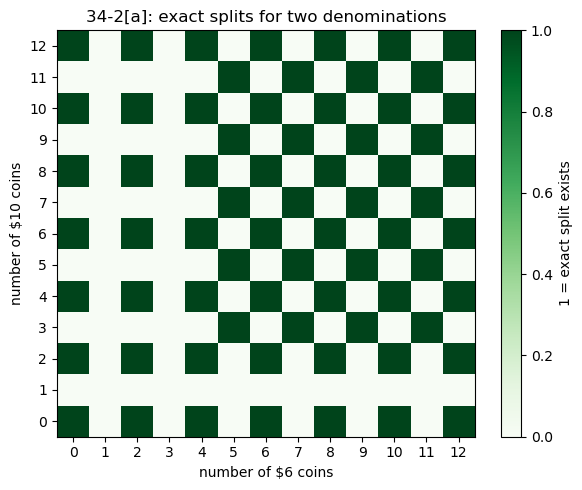

In [1]:
# Set environment.
import itertools
from collections import Counter
import sympy as sp
import matplotlib.pyplot as plt

# Define helpers.
def two_denom_split(coins):
    values = sorted(set(coins))
    if len(values) > 2:
        raise ValueError("this check is only for at most two denominations")
    total = sum(coins)
    if total % 2 != 0:
        return False, None
    target = total // 2
    if not values:
        return True, {"target": 0, "counts": {}}
    if len(values) == 1:
        x = values[0]
        if target == 0:
            return True, {"x_count": 0, "x": x, "target": target}
        if x != 0 and target % x == 0:
            i = target // x
            if 0 <= i <= len(coins):
                return True, {"x_count": i, "x": x, "target": target}
        return False, None
    x, y = values
    a = coins.count(x)
    b = coins.count(y)
    for i in range(a + 1):
        remaining = target - i * x
        if y == 0:
            if remaining == 0:
                return True, {"x_count": i, "y_count": 0, "x": x, "y": y, "target": target}
        elif remaining % y == 0:
            j = remaining // y
            if 0 <= j <= b:
                return True, {"x_count": i, "y_count": j, "x": x, "y": y, "target": target}
    return False, None

def brute_equal_split(coins):
    total = sum(coins)
    if total % 2 != 0:
        return False
    target = total // 2
    n = len(coins)
    for mask in range(1 << n):
        if sum(coins[i] for i in range(n) if mask & (1 << i)) == target:
            return True
    return False

# Simulate sample.
sample = [6] * 5 + [10] * 3
works, witness = two_denom_split(sample)
x = witness["x"]
y = witness["y"]
i = witness["x_count"]
j = witness["y_count"]
target = witness["target"]
print("sample coins:", sample)
print("target:", target)
print("algorithm says:", works, "with i,j =", (i, j))
I, J = sp.symbols("I J", integer=True, nonnegative=True)
eq = sp.Eq(x * I + y * J, target)
print("SymPy equation for the sample:", eq)
print("SymPy solves it as:", sp.solve(eq, J)[0], "for J")
print("checking witness in SymPy:", sp.simplify(x * i + y * j - target) == 0)

# Compare the algorithm against brute force on small two-denomination inputs.
all_match = True
for x in range(1, 8):
    for y in range(x + 1, 9):
        for a in range(0, 6):
            for b in range(0, 6):
                coins = [x] * a + [y] * b
                alg = two_denom_split(coins)[0]
                brute = brute_equal_split(coins)
                all_match = all_match and (alg == brute)
print("algorithm matches brute force on all small tests:", all_match)

# Plot which count-pairs are splittable for one fixed pair of denominations.
x, y = 6, 10
max_count = 12
grid = []
for b in range(max_count + 1):
    row = []
    for a in range(max_count + 1):
        row.append(two_denom_split([x] * a + [y] * b)[0])
    grid.append(row)
plt.figure(figsize=(6, 5))
plt.imshow(grid, origin="lower", cmap="Greens", aspect="auto")
plt.colorbar(label="1 = exact split exists")
plt.xlabel("number of $6 coins")
plt.ylabel("number of $10 coins")
plt.title("34-2[a]: exact splits for two denominations")
plt.xticks(range(max_count + 1))
plt.yticks(range(max_count + 1))
plt.tight_layout()
plt.show()


The code checks the linear equation $6I+10J=30$ for one sample, then compares the algorithm against brute force on many small inputs. The plot is a visual version of the same loop: green count-pairs are exactly the cases where an exact split exists.


## 34-2 [b]

The bag contains $n$ coins, with an arbitrary number of different denominations, but every denomination is a nonnegative integer power of $2$. Bonnie and Clyde wish to divide the money exactly evenly.

#### My answer:
This also has a polynomial-time algorithm.

#### My algorithm:
Let $c_k$ be the number of coins with value $2^k$. The total value is
$$
S=\sum_{k\ge 0} c_k2^k.
$$
If $S$ is odd, reject. Otherwise set $T=S/2$. Now process the binary digits of $T$ from low to high. I keep a variable called `carry`. Before bit $k$, `carry` means the number of $2^k$-sized units that can be formed from unused smaller coins. At bit $k$:

1. Compute
   $$
   \text{available}=c_k+\text{carry}.
   $$
2. Let $t_k$ be the kth binary digit of $T$.
3. If $\text{available}<t_k$, reject.
4. Otherwise use $t_k$ of those units for Bonnie's target and send
   $$
   \left\lfloor\frac{\text{available}-t_k}{2}\right\rfloor
   $$
   units upward as the new carry.

If all bits of $T$ are processed without rejection, accept. To output the actual split instead of only yes/no, we can keep the available units as bundles of original coins: start with each coin as a one-coin bundle, pair leftover bundles when carrying upward, and choose one bundle whenever a target bit is $1$. This is only polynomial extra bookkeeping.

#### Why it works:
At denomination $2^k$, only the parity matters for the kth bit of Bonnie's total. If the target bit is $1$, Bonnie needs one available $2^k$ unit; if the target bit is $0$, she needs none. Any extra pair of $2^k$ units can be treated as one $2^{k+1}$ unit, which is exactly the carry. So after bits $0,1,\ldots,k-1$ have been processed, the lower $k$ bits of Bonnie's target have already been matched, and all useful leftover lower-value coins have been summarized by the carry into bit $k$. If the algorithm rejects, the required bit cannot be made. If it finishes, every binary digit of $T$ has been made.

#### Running time:
Counting the denominations takes $O(n)$ time. The number of bit positions is at most the number of bits in the largest value plus $O(\lg n)$, so this is polynomial in the input size.


#### SymPy / Matplotlib check:


sample coins: [1, 1, 2, 4, 4, 8]
target: 10 = 0b1010
algorithm says: True
k, count of 2^k coins, carry in, available, target bit, ok
(0, 2, 0, 2, 0, True)
(1, 1, 1, 2, 1, True)
(2, 2, 0, 2, 0, True)
(3, 1, 1, 2, 1, True)
SymPy generating-function coefficient at target: 4
coefficient > 0 means target is reachable: True
algorithm matches brute force on small tests: True


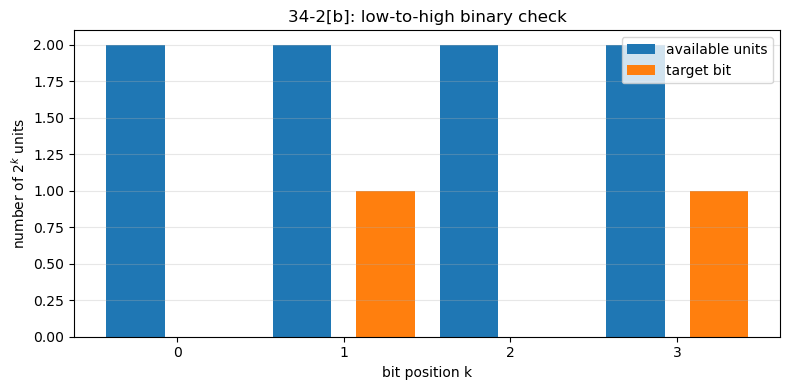

In [2]:
# Define helpers.
def power_two_split(coins):
    total = sum(coins)
    if total % 2 != 0:
        return False, []
    target = total // 2

    counts = Counter()
    for value in coins:
        if value <= 0 or value & (value - 1) != 0:
            raise ValueError("all coin values must be positive powers of 2")
        counts[value.bit_length() - 1] += 1

    carry = 0
    trace = []
    for k in range(max(1, target.bit_length())):
        target_bit = (target >> k) & 1
        available = counts[k] + carry
        ok = available >= target_bit
        trace.append((k, counts[k], carry, available, target_bit, ok))
        if not ok:
            return False, trace
        carry = (available - target_bit) // 2
    return True, trace

def brute_subset_sum(coins, target):
    n = len(coins)
    for mask in range(1 << n):
        if sum(coins[i] for i in range(n) if mask & (1 << i)) == target:
            return True
    return False

# Simulate sample.
sample = [1, 1, 2, 4, 4, 8]
works, trace = power_two_split(sample)
target = sum(sample) // 2
print("sample coins:", sample)
print("target:", target, "=", bin(target))
print("algorithm says:", works)
print("k, count of 2^k coins, carry in, available, target bit, ok")
for row in trace:
    print(row)
z = sp.symbols("z")
poly = sp.prod(1 + z**v for v in sample).expand()
coefficient = sp.Poly(poly, z).coeff_monomial(z**target)
print("SymPy generating-function coefficient at target:", coefficient)
print("coefficient > 0 means target is reachable:", coefficient > 0)

# Compare against brute force on small multisets of powers of 2.
all_match = True
small_values = [1, 2, 4, 8]
for n in range(1, 8):
    for coins in itertools.product(small_values, repeat=n):
        coins = list(coins)
        alg = power_two_split(coins)[0]
        brute = brute_subset_sum(coins, sum(coins) // 2) if sum(coins) % 2 == 0 else False
        all_match = all_match and (alg == brute)
print("algorithm matches brute force on small tests:", all_match)
bits = [row[0] for row in trace]
available = [row[3] for row in trace]
target_bits = [row[4] for row in trace]
plt.figure(figsize=(8, 4))
plt.bar([k - 0.25 for k in bits], available, width=0.35, label="available units")
plt.bar([k + 0.25 for k in bits], target_bits, width=0.35, label="target bit")
plt.xlabel("bit position k")
plt.ylabel("number of $2^k$ units")
plt.title("34-2[b]: low-to-high binary check")
plt.xticks(bits)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


The SymPy generating function multiplies one factor $(1+z^v)$ for each coin, so a positive coefficient of $z^T$ means some subset has value $T$. The plot shows the same low-to-high idea visually: at each bit, the algorithm only needs enough available units to match the target bit, and pairs move upward as carry.


## 34-2 [c]

The bag contains $n$ checks, made out to "Bonnie or Clyde." They wish to divide the checks so that they each get the exact same amount of money.

#### My answer:
This problem is $NP$-complete.

#### The problem is in $NP$:
A certificate is the set of checks Bonnie gets. To verify it, add Bonnie's checks, add Clyde's checks, and check whether the two totals are equal. This is polynomial time.

#### NP-hardness:
I reduce from `SUBSET-SUM`. An instance of `SUBSET-SUM` has numbers
$$
a_1,a_2,\ldots,a_n
$$
and a target $t$. Let
$$
A=\sum_{i=1}^n a_i.
$$
If $t>A$, the subset-sum instance is automatically a no-instance; in that case the reduction can output any fixed no-instance, for example checks $1$ and $2$. So the interesting case is $0\le t\le A$. Choose
$$
M=A+1.
$$
Now make checks with these values:
$$
a_1,a_2,\ldots,a_n,\quad M+t,\quad M+A-t.
$$
The total value of all checks is
$$
A+(M+t)+(M+A-t)=2(A+M),
$$
so each person would need exactly $A+M$ dollars. If the original subset-sum instance has a subset $X$ with sum $t$, then Bonnie can take the checks in $X$ plus the big check $M+A-t$. Her total is
$$
t+(M+A-t)=A+M,
$$
so the checks split exactly evenly. Conversely, suppose the checks can be split exactly evenly. The two big checks cannot be on the same side, because together they are worth
$$
(M+t)+(M+A-t)=A+2M>A+M.
$$
Also, a side cannot contain no big check, because all the small checks together are worth only $A<A+M$. So each side has exactly one big check. If a side has the big check $M+A-t$, then its small checks must sum to $t$. That gives a subset-sum solution. If the side has the other big check $M+t$, then the small checks on the opposite side sum to $t$. So the constructed Bonnie-and-Clyde instance is a yes-instance exactly when the original `SUBSET-SUM` instance is a yes-instance. The construction only adds two numbers and uses polynomial-time arithmetic, so this is a polynomial-time reduction. Therefore the exact-check version is $NP$-hard, and since it is also in $NP$, it is $NP$-complete.


#### SymPy / Matplotlib check:


subset-sum items: [3, 34, 4, 12, 5, 2]
subset target: 9
constructed checks: [3, 34, 4, 12, 5, 2, 70, 112]
half of constructed total: 121
subset target reachable: True
exact split reachable: True
SymPy coefficient at subset target: 2
SymPy coefficient at exact-split target: 4


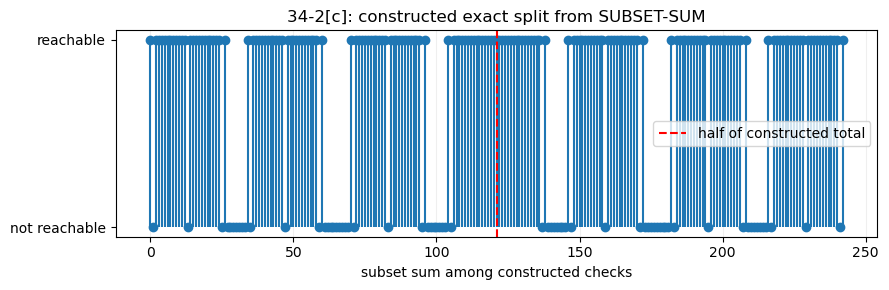

In [3]:
# Define helpers.
def reachable_subset_sums(values):
    reachable = {0}
    for value in values:
        reachable |= {s + value for s in list(reachable)}
    return reachable

def subset_sum_to_exact_split(values, target):
    A = sum(values)
    if target > A:
        raise ValueError("this helper assumes 0 <= target <= sum(values)")
    M = A + 1
    return values + [M + target, M + A - target]

# Simulate sample.
items = [3, 34, 4, 12, 5, 2]
subset_target = 9
checks = subset_sum_to_exact_split(items, subset_target)
half = sum(checks) // 2
reachable_items = reachable_subset_sums(items)
reachable_checks = reachable_subset_sums(checks)
z = sp.symbols("z")
subset_poly = sp.prod(1 + z**v for v in items).expand()
check_poly = sp.prod(1 + z**v for v in checks).expand()
subset_coeff = sp.Poly(subset_poly, z).coeff_monomial(z**subset_target)
check_coeff = sp.Poly(check_poly, z).coeff_monomial(z**half)
print("subset-sum items:", items)
print("subset target:", subset_target)
print("constructed checks:", checks)
print("half of constructed total:", half)
print("subset target reachable:", subset_target in reachable_items)
print("exact split reachable:", half in reachable_checks)
print("SymPy coefficient at subset target:", subset_coeff)
print("SymPy coefficient at exact-split target:", check_coeff)
xs = list(range(sum(checks) + 1))
ys = [1 if x in reachable_checks else 0 for x in xs]
plt.figure(figsize=(9, 3))
plt.stem(xs, ys, basefmt=" ")
plt.axvline(half, color="red", linestyle="--", label="half of constructed total")
plt.yticks([0, 1], ["not reachable", "reachable"])
plt.xlabel("subset sum among constructed checks")
plt.title("34-2[c]: constructed exact split from SUBSET-SUM")
plt.grid(True, axis="x", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


This code is not the proof by itself, but it checks the reduction idea on one concrete `SUBSET-SUM` instance. The original target $9$ is reachable, and after adding the two balancing checks, exactly half of the new total is reachable too.


## 34-2 [d]

The bag contains $n$ checks as in part (c), but this time Bonnie and Clyde are willing to accept a split in which the difference is no larger than 100 dollars.

#### My answer:
This problem is also $NP$-complete.

#### The problem is in $NP$:
Again, a certificate is the set of checks Bonnie gets. We add Bonnie's total $B$ and Clyde's total $C$, then check whether
$$
|B-C|\le 100.
$$
That check is polynomial time.

#### NP-hardness:
I reduce from the exact-check version in part [c], which is already $NP$-complete. Given an exact-check instance with values
$$
v_1,v_2,\ldots,v_n,
$$
make a new instance with values
$$
101v_1,101v_2,\ldots,101v_n.
$$
This is polynomial time because multiplying by the fixed constant $101$ only increases the input length by a constant amount. If the original instance has an exact split, then the scaled instance also has an exact split, so its difference is $0\le 100$. Conversely, every possible difference in the scaled instance is a multiple of $101$, because both Bonnie's total and Clyde's total are multiples of $101$. So if the scaled instance has a split whose difference is at most $100$, the only possible multiple of $101$ in that range is
$$
0.
$$
Therefore the scaled split is actually exact. Dividing every check by $101$ gives an exact split of the original instance. So the exact-check problem from part [c] reduces to this within-100 version. Since this problem is in $NP$ and is $NP$-hard, it is $NP$-complete.


#### SymPy / Matplotlib check:


original checks: [2, 5, 9]
has exact split: False
smallest original difference: 2
scaled checks: [202, 505, 909]
has split within 100: False
smallest scaled difference: 202
SymPy modular fact for scaled differences: True
exact_split(original) matches within_100(scaled) on small tests: True


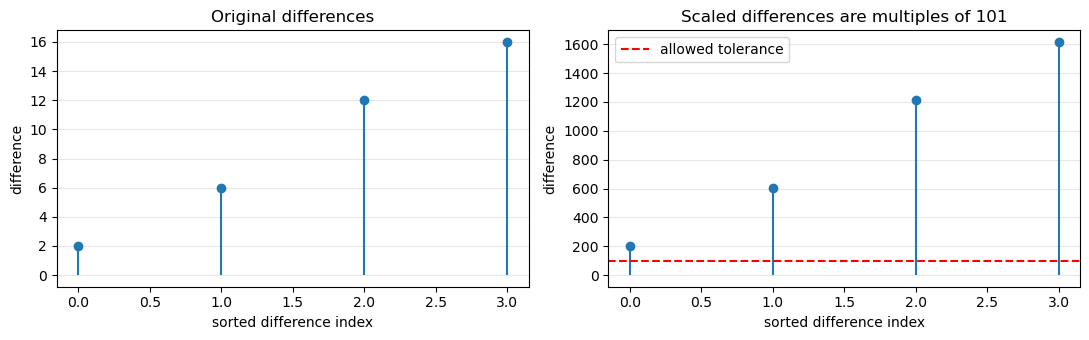

In [4]:
# Define helpers.
def possible_differences(values):
    total = sum(values)
    diffs = set()
    n = len(values)
    for mask in range(1 << n):
        bonnie = sum(values[i] for i in range(n) if mask & (1 << i))
        clyde = total - bonnie
        diffs.add(abs(bonnie - clyde))
    return sorted(diffs)

def exact_split_yes(values):
    total = sum(values)
    return total % 2 == 0 and (total // 2) in reachable_subset_sums(values)


def within_100_yes(values):
    return min(possible_differences(values)) <= 100

# Simulate sample.
no_exact = [2, 5, 9]
scaled = [101 * v for v in no_exact]
print("original checks:", no_exact)
print("has exact split:", exact_split_yes(no_exact))
print("smallest original difference:", min(possible_differences(no_exact)))
print("scaled checks:", scaled)
print("has split within 100:", within_100_yes(scaled))
print("smallest scaled difference:", min(possible_differences(scaled)))
D = sp.symbols("D", integer=True)
print("SymPy modular fact for scaled differences:", sp.Eq(sp.Mod(101 * D, 101), 0))

# Check the equivalence on many small instances.
all_match = True
for values in itertools.product(range(1, 8), repeat=5):
    original = list(values)
    scaled_values = [101 * v for v in original]
    all_match = all_match and (exact_split_yes(original) == within_100_yes(scaled_values))
print("exact_split(original) matches within_100(scaled) on small tests:", all_match)
original_diffs = possible_differences(no_exact)
scaled_diffs = possible_differences(scaled)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].stem(range(len(original_diffs)), original_diffs, basefmt=" ")
ax[0].set_title("Original differences")
ax[0].set_xlabel("sorted difference index")
ax[0].set_ylabel("difference")
ax[0].grid(True, axis="y", alpha=0.3)
ax[1].stem(range(len(scaled_diffs)), scaled_diffs, basefmt=" ")
ax[1].axhline(100, color="red", linestyle="--", label="allowed tolerance")
ax[1].set_title("Scaled differences are multiples of 101")
ax[1].set_xlabel("sorted difference index")
ax[1].set_ylabel("difference")
ax[1].grid(True, axis="y", alpha=0.3)
ax[1].legend()
plt.tight_layout()
plt.show()


The sample instance has smallest original difference $2$, so it is not an exact split. After multiplying by $101$, that smallest gap becomes $202$, already larger than the allowed tolerance of $100$. The plot shows the main reduction idea: after scaling, every nonzero difference jumps past the allowed tolerance.
